In [1]:
from astropy import units as u
from astropy.coordinates import SkyCoord

import matplotlib.pyplot as plt
from IPython.display import display
from gammapy.data import EventList
from gammapy.datasets import Datasets, MapDataset
from gammapy.irf import EDispKernelMap, PSFMap
from gammapy.maps import Map, MapAxis, WcsGeom
from gammapy.modeling import Fit
from matplotlib.patches import Circle
from gammapy.modeling.models import (
    Models,
    PointSpatialModel,
    PowerLawNormSpectralModel,
    PowerLawSpectralModel,
    SkyModel,
    TemplateSpatialModel,
    create_fermi_isotropic_diffuse_model,
)
from astropy.table import vstack
from gammapy.data import EventList
from gammapy.catalog import SourceCatalog4FGL

import yaml
from fermipy.gtanalysis import GTAnalysis


catalog_4fgl = SourceCatalog4FGL("/Users/vdk/shared/fermibottle/gll_psc_v35.fit")

In [ ]:
catalog_4fgl['']

In [13]:
files = [
    "/Users/vdk/shared/fermibottle/sgr1900+14/L250410052842F357373F73_PH00.fits",
    "/Users/vdk/shared/fermibottle/sgr1900+14/L250410052842F357373F73_PH01.fits",
    "/Users/vdk/shared/fermibottle/sgr1900+14/L250410052842F357373F73_PH02.fits",
    "/Users/vdk/shared/fermibottle/sgr1900+14/L250410052842F357373F73_PH03.fits",
    "/Users/vdk/shared/fermibottle/sgr1900+14/L250410052842F357373F73_PH04.fits",
    "/Users/vdk/shared/fermibottle/sgr1900+14/L250410052842F357373F73_PH05.fits",
    "/Users/vdk/shared/fermibottle/sgr1900+14/L250410052842F357373F73_PH06.fits",
]

# Read each file into an EventList object
event_lists = [EventList.read(f) for f in files]

# Stack the underlying tables from each EventList
merged_table = vstack([ev.table for ev in event_lists])

# Create a new EventList with the merged table
merged_events = EventList(merged_table)


In [ ]:
# name_template = "/Volumes/Crucial/astrodata/fermi_lat/sgr1900+14_alltime_15deg_radius/L2504151105455892A76E06_PH{0:02d}.fits"
# # Create a list of file names
# # using a list comprehension
# # and the format method
# # to generate the file names
# files = [name_template.format(i) for i in range(0, 6)]
# # files = [
# #     "/Volumes/Crucial/astrodata/fermi_lat/sgr1900+14_alltime_15deg_radius/L2504151105455892A76E06_PH00.fits",
# #     "/Volumes/Crucial/astrodata/fermi_lat/sgr1900+14_alltime_15deg_radius/L2504151105455892A76E06_PH01.fits",
# #     "/Volumes/Crucial/astrodata/fermi_lat/sgr1900+14_alltime_15deg_radius/L2504151105455892A76E06_PH02.fits",
# #     "/Volumes/Crucial/astrodata/fermi_lat/sgr1900+14_alltime_15deg_radius/L2504151105455892A76E06_PH03.fits",
# #     "/Volumes/Crucial/astrodata/fermi_lat/sgr1900+14_alltime_15deg_radius/L2504151105455892A76E06_PH04.fits",
# #     "/Volumes/Crucial/astrodata/fermi_lat/sgr1900+14_alltime_15deg_radius/L2504151105455892A76E06_PH05.fits", 
# # ]


# # Read each file into an EventList object
# event_lists = [EventList.read(f) for f in files]

# # Stack the underlying tables from each EventList
# merged_table = vstack([ev.table for ev in event_lists])

# # Create a new EventList with the merged table
# merged_events = EventList(merged_table)
# files

['/Volumes/Crucial/astrodata/fermi_lat/sgr1900+14_alltime_15deg_radius/L2504151105455892A76E06_PH00.fits',
 '/Volumes/Crucial/astrodata/fermi_lat/sgr1900+14_alltime_15deg_radius/L2504151105455892A76E06_PH01.fits',
 '/Volumes/Crucial/astrodata/fermi_lat/sgr1900+14_alltime_15deg_radius/L2504151105455892A76E06_PH02.fits',
 '/Volumes/Crucial/astrodata/fermi_lat/sgr1900+14_alltime_15deg_radius/L2504151105455892A76E06_PH03.fits',
 '/Volumes/Crucial/astrodata/fermi_lat/sgr1900+14_alltime_15deg_radius/L2504151105455892A76E06_PH04.fits',
 '/Volumes/Crucial/astrodata/fermi_lat/sgr1900+14_alltime_15deg_radius/L2504151105455892A76E06_PH05.fits']

In [11]:
merged_events


In [16]:
for e_min in [1, 10, 100, 300, 400, 450, 500] * u.GeV:
    n = (merged_events.energy > e_min).sum()
    print(f"Events above {e_min:4.0f}: {n:5.0f}")

Events above    1 GeV: 56776
Events above   10 GeV:  1955
Events above  100 GeV:    67
Events above  300 GeV:    10
Events above  400 GeV:     8
Events above  450 GeV:     4
Events above  500 GeV:     1


# Fermi PSF 68 containment:

 - 1 deg for 300 MeV - 1 GeV
 - 0.2 deg for 10 GeV 
 - 0.1-0.15 deg for 100 GeV

### Plotting constants

In [5]:
figsizex = 10
figsizey = 8
npix_x = 50
npix_y = 50
binsize_deg = 0.05

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")
gc_pos = SkyCoord(43.1249, 0.4301 , unit="deg", frame="galactic")

## Count map for energy range 1 GeV - 700 GeV

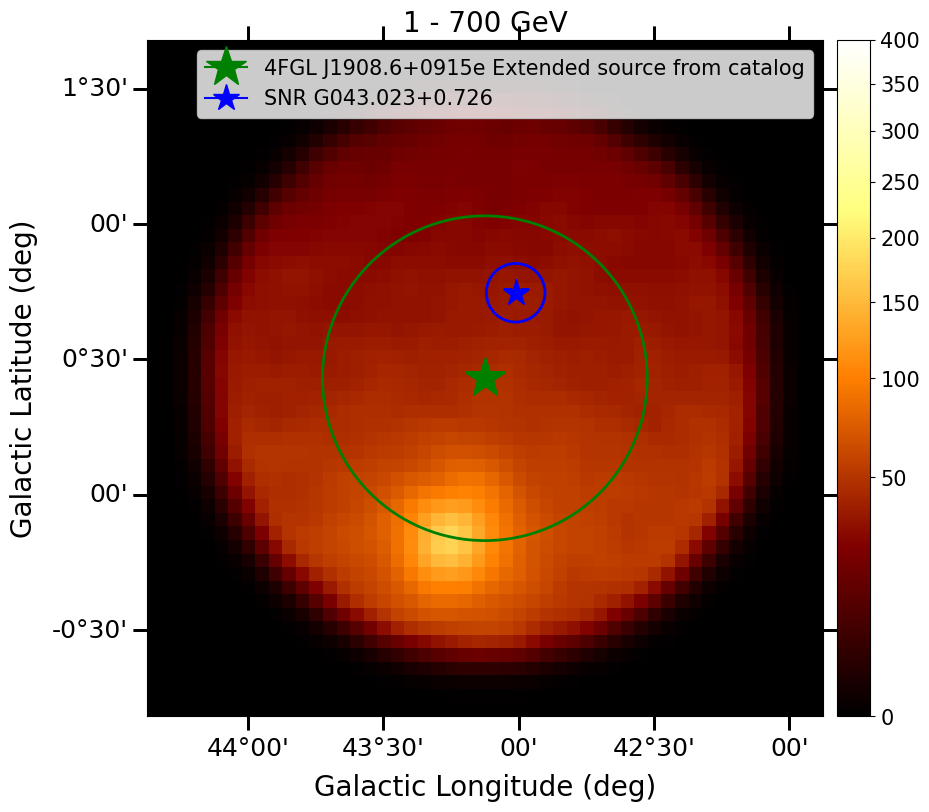

In [6]:
plt.figure(figsize=(figsizex, figsizey))

energy_axis = MapAxis.from_edges(
    [1e3, 3e4, 4e4, 5e4, 1e5, 3e5, 4e5, 7e5], name="energy", unit="MeV", interp="log"
)
counts = Map.create(
    skydir=gc_pos,
    npix=(npix_x, npix_y),
    proj="TAN",
    frame="galactic",
    binsz=binsize_deg,
    axes=[energy_axis],
    dtype=float,
)
counts.fill_events(merged_events)

#print(counts.geom.axes[0])

smoothed_map = counts.sum_over_axes().smooth(1)

# Plot and capture returned Axes
ax = smoothed_map.plot(stretch="sqrt", vmax=400, add_cbar=True)

# Plot the Fermi source position
ax.plot(
    gc_pos.l.deg, gc_pos.b.deg,
    marker='*', markersize=30, color='green',
    transform=ax.get_transform("world"),
    label="4FGL J1908.6+0915e Extended source from catalog",
)
circle = Circle(
    (gc_pos.l.deg, gc_pos.b.deg),
    0.6,  # radius in degrees
    fill=False,
    edgecolor='green',
    linewidth=2,
    transform=ax.get_transform("world")
)
ax.add_patch(circle)

# SNR G43.0+0.7 position
ax.plot(
    snr_g_043.l.deg, snr_g_043.b.deg,
    marker='*', markersize=20, color='blue',
    transform=ax.get_transform("world"),
    label="SNR G043.023+0.726",
)
snr_circle = Circle(
    (snr_g_043.l.deg, snr_g_043.b.deg),
    0.10833,
    fill=False,
    edgecolor='blue',
    linewidth=2,
    transform=ax.get_transform("world")
)
ax.add_patch(snr_circle)

ax.set_xlabel("Galactic Longitude (deg)", fontsize=20)
ax.set_ylabel("Galactic Latitude (deg)", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18, width=2, length=10)
ax.legend(fontsize=15)


plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
ax.set_title("1 - 700 GeV", fontsize=20)
plt.show()


## Count map for energy range 10 GeV - 700 GeV

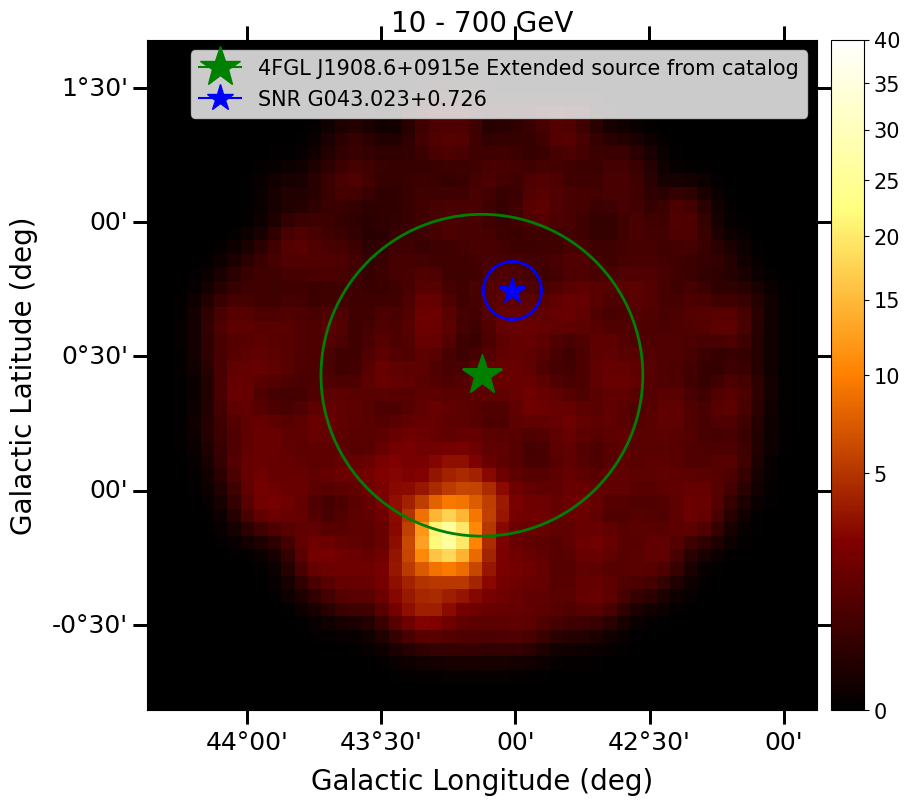

In [134]:
plt.figure(figsize=(figsizex, figsizey))
gc_pos = SkyCoord(43.1249, 0.4301 , unit="deg", frame="galactic")
energy_axis = MapAxis.from_edges(
    [1e4, 3e4, 4e4, 5e4, 1e5, 3e5, 4e5, 7e5], name="energy", unit="MeV", interp="log"
)
counts = Map.create(
    skydir=gc_pos,
    npix=(npix_x, npix_y),
    proj="TAN",
    frame="galactic",
    binsz=binsize_deg,
    axes=[energy_axis],
    dtype=float,
)
counts.fill_events(merged_events)

#print(counts.geom.axes[0])

smoothed_map = counts.sum_over_axes().smooth(1)

# Plot and capture returned Axes
ax = smoothed_map.plot(stretch="sqrt", vmax=40, add_cbar=True)


ax.set_xlabel("Galactic Longitude (deg)", fontsize=20)
ax.set_ylabel("Galactic Latitude (deg)", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18, width=2, length=10)

# Plot the Fermi source position
ax.plot(
    gc_pos.l.deg, gc_pos.b.deg,
    marker='*', markersize=30, color='green',
    transform=ax.get_transform("world"),
    label="4FGL J1908.6+0915e Extended source from catalog",
)
circle = Circle(
    (gc_pos.l.deg, gc_pos.b.deg),
    0.6,  # radius in degrees
    fill=False,
    edgecolor='green',
    linewidth=2,
    transform=ax.get_transform("world")
)

ax.plot(
    snr_g_043.l.deg, snr_g_043.b.deg,
    marker='*', markersize=20, color='blue',
    transform=ax.get_transform("world"),
    label="SNR G043.023+0.726",
)
# Create circle around SNR
snr_circle = Circle(
    (snr_g_043.l.deg, snr_g_043.b.deg),
    0.10833,  # radius in degrees
    fill=False,
    edgecolor='blue',
    linewidth=2,
    transform=ax.get_transform("world")
)
ax.add_patch(snr_circle)


ax.legend(fontsize=15
          )
ax.add_patch(circle)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
ax.set_title("10 - 700 GeV", fontsize=20)
plt.show()


## Counts for energy range 100 GeV - 700 GeV

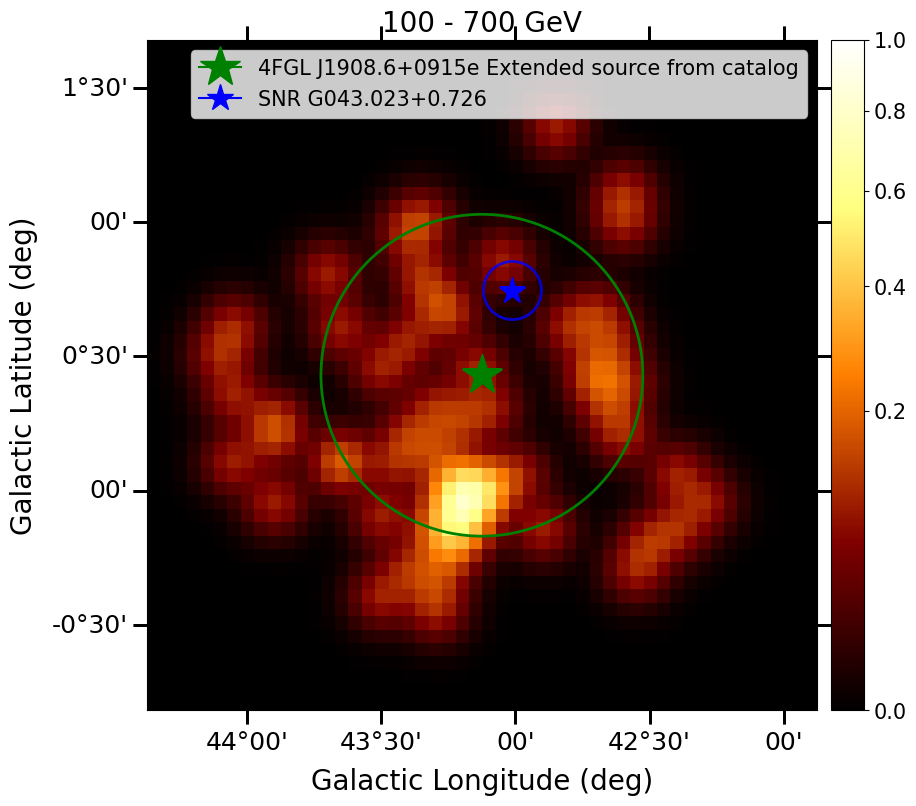

In [135]:
plt.figure(figsize=(figsizex, figsizey))
gc_pos = SkyCoord(43.1249, 0.4301 , unit="deg", frame="galactic")
energy_axis = MapAxis.from_edges(
    [1e5, 2e5, 3e5, 4e5, 5e5, 7e5], name="energy", unit="MeV", interp="log"
)
counts = Map.create(
    skydir=gc_pos,
    npix=(npix_x, npix_y),
    proj="TAN",
    frame="galactic",
    binsz=binsize_deg,
    axes=[energy_axis],
    dtype=float,
)
counts.fill_events(merged_events)

#print(counts.geom.axes[0])
# Smoothing choosed to match Fermi PSF
smoothed_map = counts.sum_over_axes().smooth(0.066 * u.deg)

# Plot and capture returned Axes
ax = smoothed_map.plot(stretch="sqrt", vmax=1, add_cbar=True)


ax.set_xlabel("Galactic Longitude (deg)", fontsize=20)
ax.set_ylabel("Galactic Latitude (deg)", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18, width=2, length=10)

# Plot the Fermi source position
ax.plot(
    gc_pos.l.deg, gc_pos.b.deg,
    marker='*', markersize=30, color='green',
    transform=ax.get_transform("world"),
    label="4FGL J1908.6+0915e Extended source from catalog",
)
circle = Circle(
    (gc_pos.l.deg, gc_pos.b.deg),
    0.6,  # radius in degrees
    fill=False,
    edgecolor='green',
    linewidth=2,
    transform=ax.get_transform("world")
)

ax.plot(
    snr_g_043.l.deg, snr_g_043.b.deg,
    marker='*', markersize=20, color='blue',
    transform=ax.get_transform("world"),
    label="SNR G043.023+0.726",
)
# Create circle around SNR
snr_circle = Circle(
    (snr_g_043.l.deg, snr_g_043.b.deg),
    0.1083,  # radius in degrees
    fill=False,
    alpha=0.8,
    edgecolor='blue',
    linewidth=2,
    transform=ax.get_transform("world")
)
ax.add_patch(snr_circle)


ax.legend(fontsize=15)
ax.add_patch(circle)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
ax.set_title("100 - 700 GeV", fontsize=20)
plt.show()


## Counts for energy range 300 GeV - 700 GeV

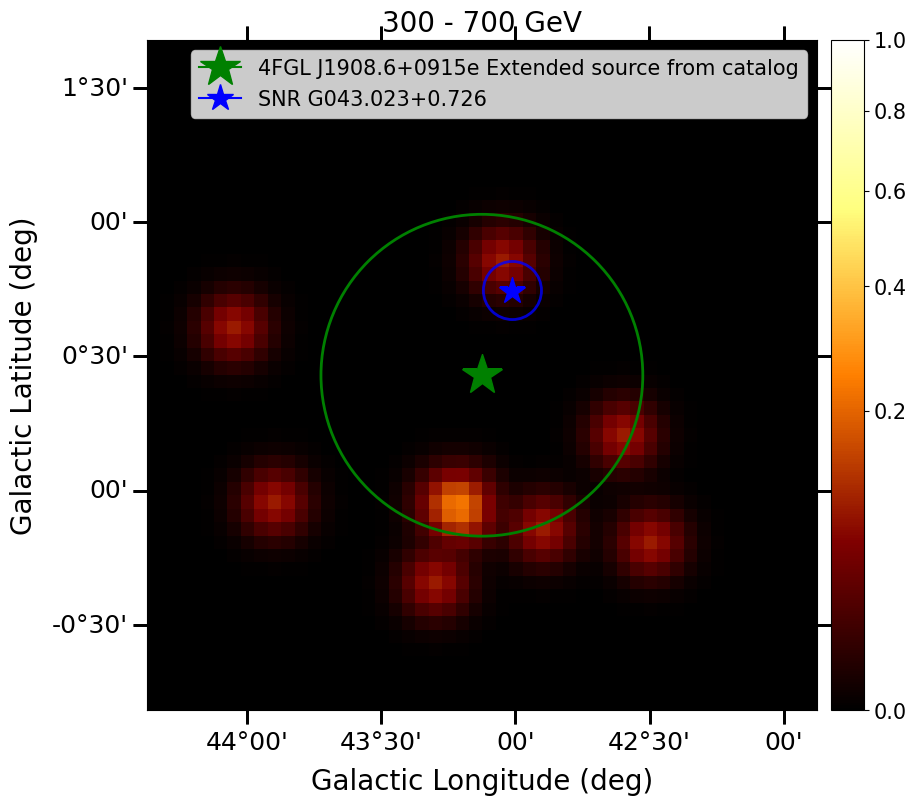

In [139]:
plt.figure(figsize=(figsizex, figsizey))
gc_pos = SkyCoord(43.1249, 0.4301 , unit="deg", frame="galactic")
energy_axis = MapAxis.from_edges(
    [3e5, 4e5, 5e5, 7e5], name="energy", unit="MeV", interp="log"
)
counts = Map.create(
    skydir=gc_pos,
    npix=(npix_x, npix_y),
    proj="TAN",
    frame="galactic",
    binsz=binsize_deg,
    axes=[energy_axis],
    dtype=float,
)
counts.fill_events(merged_events)

#print(counts.geom.axes[0])
# Smoothing choosed to match Fermi PSF
smoothed_map = counts.sum_over_axes().smooth(0.066 * u.deg)

# Plot and capture returned Axes
ax = smoothed_map.plot(stretch="sqrt", vmax=1, add_cbar=True)


ax.set_xlabel("Galactic Longitude (deg)", fontsize=20)
ax.set_ylabel("Galactic Latitude (deg)", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18, width=2, length=10)

# Plot the Fermi source position
ax.plot(
    gc_pos.l.deg, gc_pos.b.deg,
    marker='*', markersize=30, color='green',
    transform=ax.get_transform("world"),
    label="4FGL J1908.6+0915e Extended source from catalog",
)
circle = Circle(
    (gc_pos.l.deg, gc_pos.b.deg),
    0.6,  # radius in degrees
    fill=False,
    edgecolor='green',
    linewidth=2,
    transform=ax.get_transform("world")
)

ax.plot(
    snr_g_043.l.deg, snr_g_043.b.deg,
    marker='*', markersize=20, color='blue',
    transform=ax.get_transform("world"),
    label="SNR G043.023+0.726",
)
# Create circle around SNR
snr_circle = Circle(
    (snr_g_043.l.deg, snr_g_043.b.deg),
    0.1083,  # radius in degrees
    fill=False,
    alpha=0.8,
    edgecolor='blue',
    linewidth=2,
    transform=ax.get_transform("world")
)
ax.add_patch(snr_circle)


ax.legend(fontsize=15)
ax.add_patch(circle)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
ax.set_title("300 - 700 GeV", fontsize=20)
plt.show()


# Fermipy analysis of the source region

In [13]:
# Create a GTAnalysis object from the configuration file.
gta = GTAnalysis('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/fermi_config_tutorial.yaml', logging={'verbosity': 3})

2025-04-10 13:55:33 INFO    GTAnalysis.__init__(): 
--------------------------------------------------------------------------------
fermipy version 1.3.1 
ScienceTools version 2.2.0


To create one event file:

```
ls ./*PH*.fits > ./PH.txt
```

In [14]:
gta.setup()

2025-04-10 13:55:34 INFO    GTAnalysis.setup(): Running setup.
2025-04-10 13:55:34 INFO    GTBinnedAnalysis.setup(): Running setup for component 00
2025-04-10 13:55:34 INFO    GTBinnedAnalysis.run_gtapp(): Running gtselect.
2025-04-10 13:55:34 INFO    GTBinnedAnalysis.run_gtapp(): time -p gtselect infile=/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/output_sgr/evfile_00.txt outfile=/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/output_sgr/ft1_00.fits ra=287.15994750303526 dec=9.259972392984793 rad=1.2071067811865475 tmin=239557417.0 tmax=765936005.0 emin=1000.0 emax=1000000.0 zmin=0.0 zmax=90.0 evclass=128 evtype=3 convtype=-1 phasemin=0.0 phasemax=1.0 evtable="EVENTS" chatter=3 clobber=yes debug=no gui=no mode="ql"
2025-04-10 13:55:34 INFO    GTBinnedAnalysis.run_gtapp(): This is gtselect version HEAD
2025-04-10 13:55:34 INFO    GTBinnedAnalysis.run_gtapp(): Applying filter string: ((EVENT_CLASS&o200) != o0) && angsep(RA,DEC,287.16,9.26) < 1 && ((EVENT

In [25]:
gta.optimize()

2025-04-10 15:46:32 INFO    GTAnalysis.optimize(): Starting
2025-04-10 15:46:32 INFO    GTAnalysis.optimize(): Finished
2025-04-10 15:46:32 INFO    GTAnalysis.optimize(): LogLike: 0.000000 Delta-LogLike: 0.000000
2025-04-10 15:46:32 INFO    GTAnalysis.optimize(): Execution time: 0.01 s


Joint fit  []


{'loglike0': 0.0,
 'loglike1': 0.0,
 'dloglike': 0.0,
 'config': {'npred_threshold': 1.0,
  'npred_frac': 0.95,
  'shape_ts_threshold': 25.0,
  'max_free_sources': 5,
  'skip': [],
  'optimizer': {'optimizer': 'MINUIT',
   'tol': 0.001,
   'max_iter': 100,
   'init_lambda': 0.0001,
   'retries': 3,
   'min_fit_quality': 2,
   'verbosity': 0}}}

In [26]:
gta.print_roi()

2025-04-10 15:46:35 INFO    GTAnalysis.print_roi(): 
name                SpatialModel   SpectrumType     offset        ts       npred
--------------------------------------------------------------------------------



In [71]:
gta

In [ ]:
psf_dict = gta.compute_psf(True, thetamax=1.4)
# Optionally, you can plot the PSF. This produces an image file (e.g., 'psf.png') showing the PSF versus angle.
gta.plot_psf(psf_dict, outfile='psf.png')

# Counts map after filtering

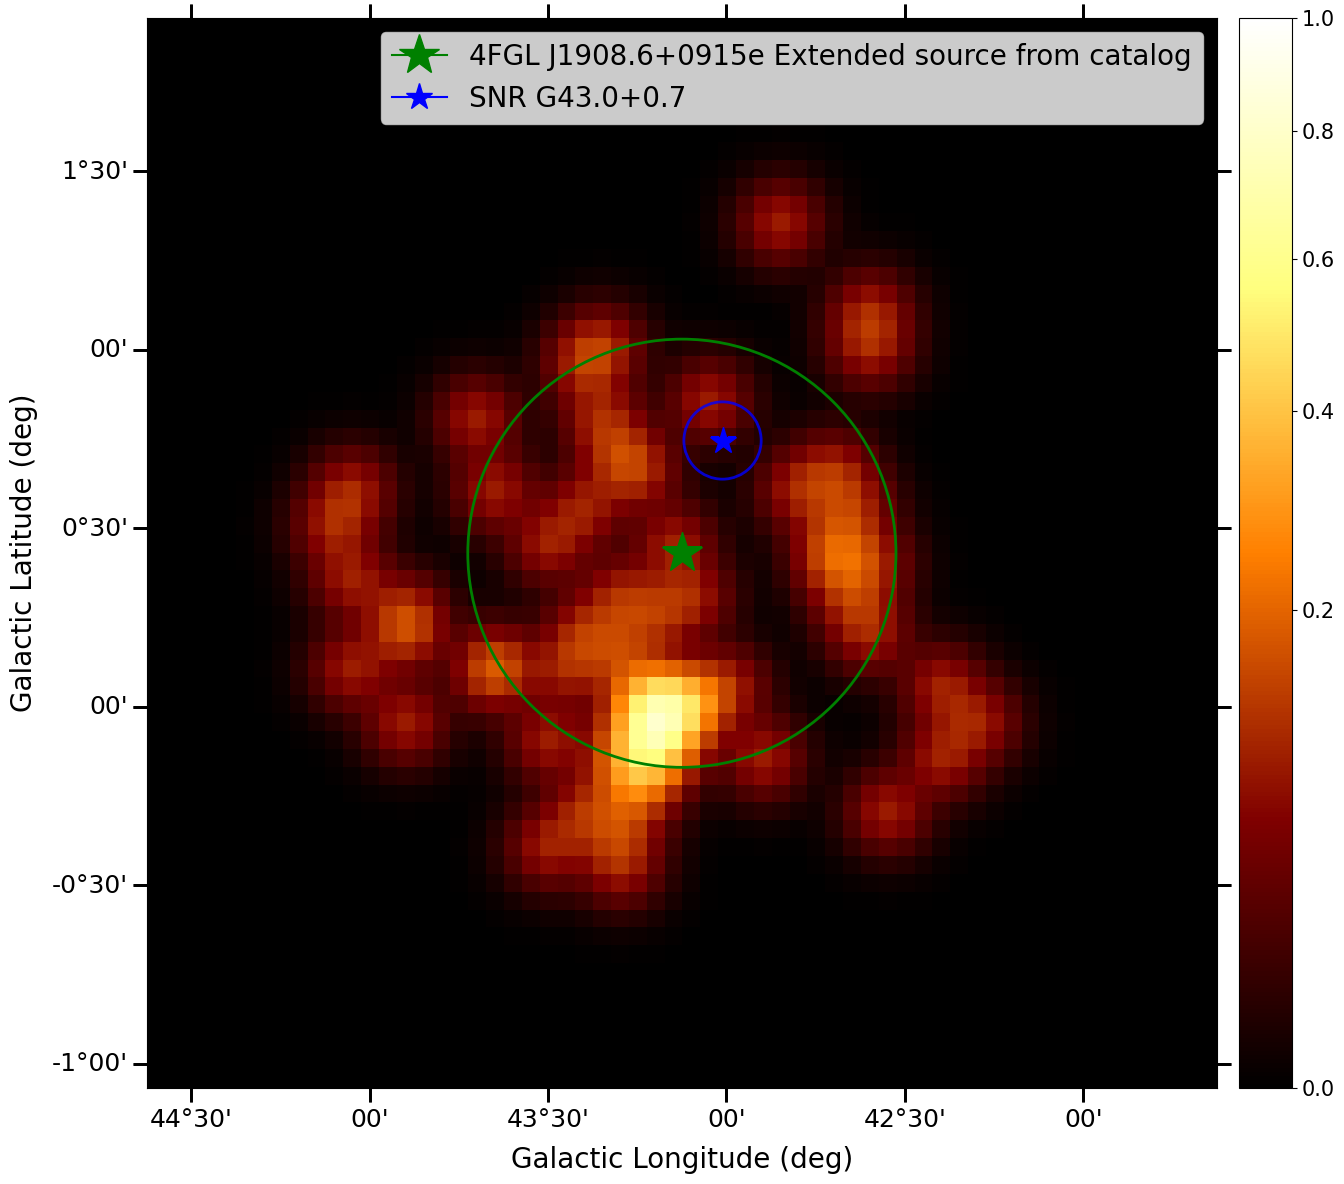

In [24]:
# Read the filtered FT1 files produced by gta.setup()
filtered_files = [
    "/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/output_sgr/ft1_00.fits"
    # Add more filtered files if there are multiple components
]

# Read each filtered file into an EventList object
filtered_event_lists = [EventList.read(f) for f in filtered_files]

# Stack the underlying tables if you have multiple files
if len(filtered_event_lists) > 1:
    filtered_table = vstack([ev.table for ev in filtered_event_lists])
    filtered_events = EventList(filtered_table)
else:
    filtered_events = filtered_event_lists[0]

# Create the counts map exactly as before, but with filtered_events
plt.figure(figsize=(figsizex, figsizey))
energy_axis = MapAxis.from_edges(
    [1e5, 2e5, 3e5, 4e5, 5e5], name="energy", unit="MeV", interp="log"
)
counts = Map.create(
    skydir=gc_pos,
    npix=(npix_x, npix_y),
    proj="TAN",
    frame="galactic",
    binsz=binsize_deg,
    axes=[energy_axis],
    dtype=float,
)
counts.fill_events(filtered_events)

# Same smoothing and plotting code as before
smoothed_map = counts.sum_over_axes().smooth(0.066 * u.deg)
ax = smoothed_map.plot(stretch="sqrt", vmax=1, add_cbar=True)

# Rest of your visualization code remains identical
ax.set_xlabel("Galactic Longitude (deg)", fontsize=20)
ax.set_ylabel("Galactic Latitude (deg)", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18, width=2, length=10)

# Plot the Fermi source position
ax.plot(
    gc_pos.l.deg, gc_pos.b.deg,
    marker='*', markersize=30, color='green',
    transform=ax.get_transform("world"),
    label="4FGL J1908.6+0915e Extended source from catalog",
)
circle = Circle(
    (gc_pos.l.deg, gc_pos.b.deg),
    0.6,  # radius in degrees
    fill=False,
    edgecolor='green',
    linewidth=2,
    transform=ax.get_transform("world")
)

ax.plot(
    snr_g_043.l.deg, snr_g_043.b.deg,
    marker='*', markersize=20, color='blue',
    transform=ax.get_transform("world"),
    label="SNR G43.0+0.7",
)
# Create circle around SNR
snr_circle = Circle(
    (snr_g_043.l.deg, snr_g_043.b.deg),
    0.1083,  # radius in degrees
    fill=False,
    alpha=0.8,
    edgecolor='blue',
    linewidth=2,
    transform=ax.get_transform("world")
)
ax.add_patch(snr_circle)


ax.legend(fontsize=20)
ax.add_patch(circle)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()

plt.show()

# Catalog processing

In [74]:
catalog_4fgl

In [75]:
source = catalog_4fgl["4FGL J1908.6+0915e"]
print(source.data)  # See available information

{'Source_Name': '4FGL J1908.6+0915e', 'DataRelease': 1, 'RAJ2000': <Quantity 287.16 deg>, 'DEJ2000': <Quantity 9.26 deg>, 'GLON': <Quantity 43.12494 deg>, 'GLAT': <Quantity 0.43006942 deg>, 'Conf_68_SemiMajor': <Quantity 0. deg>, 'Conf_68_SemiMinor': <Quantity 0. deg>, 'Conf_68_PosAng': <Quantity 0. deg>, 'Conf_95_SemiMajor': <Quantity 0. deg>, 'Conf_95_SemiMinor': <Quantity 0. deg>, 'Conf_95_PosAng': <Quantity 0. deg>, 'ROI_num': 55, 'Extended_Source_Name': 'G42.8+0.6         ', 'Signif_Avg': 6.58566, 'Pivot_Energy': <Quantity 4195.5376 MeV>, 'Flux1000': <Quantity 2.4872044e-09 1 / (s cm2)>, 'Unc_Flux1000': <Quantity 3.7204115e-10 1 / (s cm2)>, 'Energy_Flux100': <Quantity 2.8496226e-11 erg / (s cm2)>, 'Unc_Energy_Flux100': <Quantity 4.735714e-12 erg / (s cm2)>, 'SpectrumType': 'PowerLaw         ', 'PL_Flux_Density': <Quantity 1.2764571e-13 1 / (MeV s cm2)>, 'Unc_PL_Flux_Density': <Quantity 1.789627e-14 1 / (MeV s cm2)>, 'PL_Index': 2.2013872, 'Unc_PL_Index': 0.084273666, 'LP_Flux_Dens

## Significance of the detection

In [64]:
source.data['Signif_Avg']

6.58566

In [8]:
for keys in source.data.keys():
    print(keys)

Source_Name
DataRelease
RAJ2000
DEJ2000
GLON
GLAT
Conf_68_SemiMajor
Conf_68_SemiMinor
Conf_68_PosAng
Conf_95_SemiMajor
Conf_95_SemiMinor
Conf_95_PosAng
ROI_num
Extended_Source_Name
Signif_Avg
Pivot_Energy
Flux1000
Unc_Flux1000
Energy_Flux100
Unc_Energy_Flux100
SpectrumType
PL_Flux_Density
Unc_PL_Flux_Density
PL_Index
Unc_PL_Index
LP_Flux_Density
Unc_LP_Flux_Density
LP_Index
Unc_LP_Index
LP_beta
Unc_LP_beta
LP_SigCurv
LP_EPeak
Unc_LP_EPeak
PLEC_Flux_Density
Unc_PLEC_Flux_Density
PLEC_IndexS
Unc_PLEC_IndexS
PLEC_ExpfactorS
Unc_PLEC_ExpfactorS
PLEC_Exp_Index
Unc_PLEC_Exp_Index
PLEC_SigCurv
PLEC_EPeak
Unc_PLEC_EPeak
Npred
Flux_Band
Unc_Flux_Band
nuFnu_Band
Sqrt_TS_Band
Variability_Index
Frac_Variability
Unc_Frac_Variability
Signif_Peak
Flux_Peak
Unc_Flux_Peak
Time_Peak
Peak_Interval
Flux_History
Unc_Flux_History
Sqrt_TS_History
ASSOC_4FGL
ASSOC_FGL
ASSOC_FHL
ASSOC_GAM1
ASSOC_GAM2
ASSOC_GAM3
TEVCAT_FLAG
ASSOC_TEV
CLASS1
CLASS2
ASSOC1
ASSOC2
ASSOC_PROB_BAY
ASSOC_PROB_LR
RA_Counterpart
DEC_Co

In [45]:
source.spatial_model()

In [46]:
source.spectral_model()

In [20]:
from gammapy.modeling.models import SkyModel

spectral_model = source.spectral_model()

spatial_model = source.spatial_model()

model = SkyModel(spectral_model=spectral_model, spatial_model=spatial_model, name="mysource")

In [ ]:
from gammapy.maps import WcsGeom, MapAxis
from gammapy.data import DataStore
from gammapy.makers import MapDatasetMaker, SafeMaskMaker
from gammapy.modeling.models import SkyModel

# Example geometry
axis_energy = MapAxis.from_energy_bounds("100 MeV", "100 GeV", nbin=10, name="energy")
geom = WcsGeom.create(
    skydir=(" deg", "0 deg"),  # ROI center
    width=(10, 10),            # 10x10 deg
    axes=[axis_energy]
)

# Build the dataset
dataset_maker = MapDatasetMaker(selection=["counts", "exposure", "psf", "edisp"])
safe_mask_maker = SafeMaskMaker(methods=["aeff-default", "offset-max"], offset_max="5 deg")


In [26]:
events = EventList.read("/Users/vdk/shared/fermibottle/L250402072247F6FCB56E91_PH00.fits")
print(events)

EventList
---------

  Instrument       : LAT
  Telescope        : GLAST
  Obs. ID          : 

  Number of events : 39090
  Event rate       : 0.001 1 / s

  Time start       : 54682.65603222222
  Time stop        : 55566.99228222222

  Min. energy      : 1.00e+02 MeV
  Max. energy      : 2.84e+05 MeV
  Median energy    : 4.25e+02 MeV




In [78]:
print(events.table.colnames)

display(events.table[:5][["ENERGY", "RA", "DEC"]])

print(events.time[0].iso)
print(events.time[-1].iso)

energy = events.energy
energy.info("stats")

NameError: name 'events' is not defined

In [29]:
for e_min in [10, 100, 1000] * u.GeV:
    n = (events.energy > e_min).sum()
    print(f"Events above {e_min:4.0f}: {n:5.0f}")

Events above   10 GeV:   282
Events above  100 GeV:     8
Events above 1000 GeV:     0


In [ ]:

print(merged_events.table.colnames)

display(merged_events.table[:5][["ENERGY", "RA", "DEC"]])

print(merged_events.time[0].iso)
print(merged_events.time[-1].iso)

energy = merged_events.energy
energy.info("stats")

['ENERGY', 'RA', 'DEC', 'L', 'B', 'THETA', 'PHI', 'ZENITH_ANGLE', 'EARTH_AZIMUTH_ANGLE', 'TIME', 'EVENT_ID', 'RUN_ID', 'RECON_VERSION', 'CALIB_VERSION', 'EVENT_CLASS', 'EVENT_TYPE', 'CONVERSION_TYPE', 'LIVETIME', 'DIFRSP0', 'DIFRSP1', 'DIFRSP2', 'DIFRSP3', 'DIFRSP4']


ENERGY,RA,DEC
MeV,deg,deg
float32,float32,float32
195.84473,286.66052,9.534511
739.0282,287.5653,8.953771
678.7906,287.901,9.74029
166.80879,286.8806,9.226936
489.15988,287.96515,9.854529


2008-08-04 16:22:38.811
2025-04-02 05:49:10.707
name = ENERGY
mean = 951.151 MeV
std = 3324.03 MeV
min = 100.001 MeV
max = 283742 MeV
n_bad = 0
length = 265273


In [ ]:
for e_min in [10, 100, 1000] * u.GeV:
    n = (merged_events.energy > e_min).sum()
    print(f"Events above {e_min:4.0f}: {n:5.0f}")

Events above   10 GeV:  1940
Events above  100 GeV:    57
Events above 1000 GeV:     0


MapAxis

	name       : energy    
	unit       : 'MeV'     
	nbins      : 7         
	node type  : edges     
	edges min  : 1.0e+04 MeV
	edges max  : 5.0e+05 MeV
	interp     : log       



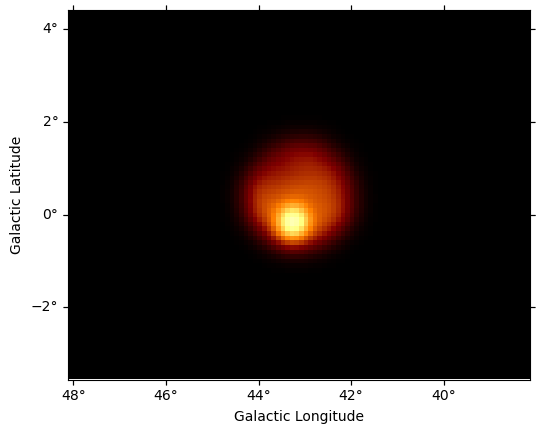

In [ ]:
gc_pos = SkyCoord(43.1249, 0.4301 , unit="deg", frame="galactic")
energy_axis = MapAxis.from_edges(
    [1e4, 3e4, 4e4, 5e4, 1e5, 3e5, 4e5, 5e5], name="energy", unit="MeV", interp="log"
)
counts = Map.create(
    skydir=gc_pos,
    npix=(100, 80),
    proj="TAN",
    frame="galactic",
    binsz=0.1,
    axes=[energy_axis],
    dtype=float,
)
# We put this call into the same Jupyter cell as the Map.create
# because otherwise we could accidentally fill the counts
# multiple times when executing the `fill_by_coord` multiple times.
counts.fill_events(merged_events)

print(counts.geom.axes[0])

counts.sum_over_axes().smooth(2).plot(stretch="sqrt", vmax=30)

plt.show()

In [ ]:
# List your FITS event files
files = [
    "/Users/vdk/Downloads/L250402074957F6FCB56E09_PH00.fits",
    "/Users/vdk/Downloads/L250402074957F6FCB56E09_PH01.fits",
    "/Users/vdk/Downloads/L250402074957F6FCB56E09_PH02.fits",
    "/Users/vdk/Downloads/L250402074957F6FCB56E09_PH03.fits",
]

# Read each file into an EventList object
event_lists = [EventList.read(f) for f in files]

# Stack the underlying tables from each EventList
merged_table_2 = vstack([ev.table for ev in event_lists])

# Create a new EventList with the merged table
merged_events_2 = EventList(merged_table_2)

MapAxis

	name       : energy    
	unit       : 'MeV'     
	nbins      : 7         
	node type  : edges     
	edges min  : 1.0e+04 MeV
	edges max  : 5.0e+05 MeV
	interp     : log       



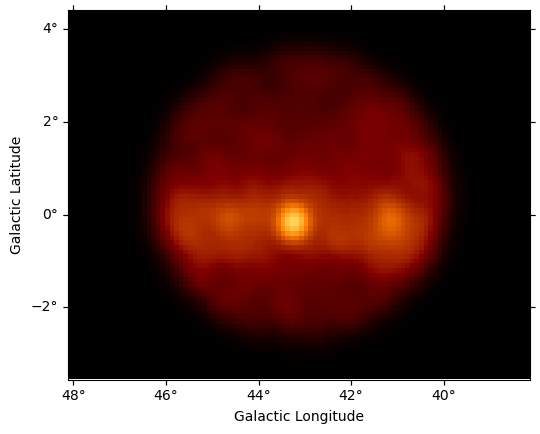

In [ ]:
events = EventList.read("/Users/vdk/Downloads/L250402074957F6FCB56E09_PH00.fits")
gc_pos = SkyCoord(43.1249, 0.4301 , unit="deg", frame="galactic")
energy_axis = MapAxis.from_edges(
    [1e4, 3e4, 4e4, 5e4, 1e5, 3e5, 4e5, 5e5], name="energy", unit="MeV", interp="log"
)
counts = Map.create(
    skydir=gc_pos,
    npix=(100, 80),
    proj="TAN",
    frame="galactic",
    binsz=0.1,
    axes=[energy_axis],
    dtype=float,
)
# We put this call into the same Jupyter cell as the Map.create
# because otherwise we could accidentally fill the counts
# multiple times when executing the `fill_by_coord` multiple times.
counts.fill_events(merged_events_2)

print(counts.geom.axes[0])

counts.sum_over_axes().smooth(2).plot(stretch="sqrt", vmax=30)

plt.show()